In [1]:
import orb as orb
from orcs.process import SpectralCube

import numpy as np
from photutils.detection import DAOStarFinder
from photutils import CircularAperture
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.stats import sigma_clipped_stats
from astropy.io import fits
from astropy.table import QTable

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os

In [ ]:
# input_cube_path='../M106/M106_cubes_hdf5/'
# path_cube_reference = '/arc/home/emmajarvis/M94_Field1.2738943z.SN3.hdf5'
# path_cube_desaligne = '/arc/home/emmajarvis/M94_Field1.2739140z.SN1.hdf5'
# path_cube_desaligne = '/arc/home/emmajarvis/M94_Field1.2752804z.SN2.hdf5'


field = 'F5'

filter_to_align = 'SN1'

if field == 'NW':
    path_cube_reference = '/arc/projects/signals/M33/M33-NW_SN3.merged.cm1.1.0.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33/M33-NW_SN2.merged.cm1.1.0.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33/M33-NW.2190905z.SN1.hdf5'
        
if field == 'NE':
    path_cube_reference = '/arc/projects/signals/M33/M33-NE.2204014z.SN3.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33/M33-NE_SN2.merged.cm1.1.0.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33/M33-NE_SN1.merged.cm1.1.0.hdf5'
        
if field == 'SE':
    path_cube_reference = '/arc/projects/signals/M33/M33-SE_SN3.merged.cm1.1.0.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33/M33-SE_SN2.merged.cm1.1.0.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33/M33-SE_SN1.merged.cm1.1.0.hdf5'
        
if field == 'SW':
    path_cube_reference = '/arc/projects/signals/M33/M33-SW_SN3.merged.cm1.1.0.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33/M33-SW_SN2.merged.cm1.1.0.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33/M33-SW_SN1.merged.cm1.1.0.hdf5'
        
        
if field == 'F5':
    path_cube_reference = '/arc/projects/signals/M33_Field5_SN1.merged.cm1.1.0.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33/M33_Field5.2655759z.SN2.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33_Field5_SN1.merged.cm1.1.0.hdf5'
        
        
if field == 'F6':
    path_cube_reference = '/arc/projects/signals/M33_Field6_SN2.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33_Field6_SN2.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33/M33_Field6.2683764z.SN1.hdf5'
        
        
if field == 'F7':
    # path_cube_reference = '/arc/projects/signals/M33_Field7.2309128z.SN3.hdf5'
    path_cube_reference = '/arc/projects/signals/M33_Field7.2325242z.SN2.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33_Field7.2325242z.SN2.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33_Field7.2326978z.SN1.hdf5'
        
        
if field == 'F8':
    path_cube_reference = '/arc/projects/signals/M33_FIELD8_SN3_20BP41.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33_FIELD8_SN2_20BP41.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33_FIELD8_SN1_20BP41.hdf5'
        
if field == 'F9':
    path_cube_reference = '/arc/projects/signals/M33_FIELD9_SN3_19BP41.hdf5'
    if filter_to_align =='SN2':
        path_cube_desaligne = '/arc/projects/signals/M33_FIELD9_SN2_20BP41.hdf5'
    if filter_to_align =='SN1':
        path_cube_desaligne = '/arc/projects/signals/M33_FIELD9_SN1_20BP41.hdf5'

In [3]:
cube_reference = SpectralCube(path_cube_reference)
cube_desaligne = SpectralCube(path_cube_desaligne)
deep_frame_reference = cube_reference.get_deep_frame().data.T
deep_frame_desaligne = cube_desaligne.get_deep_frame().data.T

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 505)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False
unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 219)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False


In [4]:
'''
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
fig1 = ax1.imshow(deep_frame_reference,
                    vmin=np.nanpercentile(deep_frame_reference, 10),
                    vmax=np.nanpercentile(deep_frame_reference, 99),
                    origin='lower',
                    cmap='magma')
plt.colorbar(fig1, ax=ax1)
ax2.hist(deep_frame_reference.ravel(), 50, range=(100000,500000), color='palevioletred')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
fig1 = ax1.imshow(deep_frame_desaligne,
                    vmin=np.nanpercentile(deep_frame_desaligne, 10),
                    vmax=np.nanpercentile(deep_frame_desaligne, 99),
                    origin='lower',
                    cmap='magma')
plt.colorbar(fig1, ax=ax1)
ax2.hist(deep_frame_desaligne.ravel(), 50, range=(100000,500000), color='palevioletred')
plt.show()
'''

"\nfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))\nfig1 = ax1.imshow(deep_frame_reference,\n                    vmin=np.nanpercentile(deep_frame_reference, 10),\n                    vmax=np.nanpercentile(deep_frame_reference, 99),\n                    origin='lower',\n                    cmap='magma')\nplt.colorbar(fig1, ax=ax1)\nax2.hist(deep_frame_reference.ravel(), 50, range=(100000,500000), color='palevioletred')\nplt.show()\n\nfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))\nfig1 = ax1.imshow(deep_frame_desaligne,\n                    vmin=np.nanpercentile(deep_frame_desaligne, 10),\n                    vmax=np.nanpercentile(deep_frame_desaligne, 99),\n                    origin='lower',\n                    cmap='magma')\nplt.colorbar(fig1, ax=ax1)\nax2.hist(deep_frame_desaligne.ravel(), 50, range=(100000,500000), color='palevioletred')\nplt.show()\n"

In [5]:
def detect_stars(deep_frame):
    mean, median, std = sigma_clipped_stats(deep_frame, sigma=3.0)

    ## Define the threshold for stars detection here
    thresh = 50.*std
    daofind = DAOStarFinder(fwhm=3.0, threshold=thresh)  
    print('threshold = ',thresh)
    stars = daofind(deep_frame)  
    if stars is None or len(stars) == 0:
        raise RuntimeError('No stars detected. Lower the DAOStarFinder threshold or check the deep frame.')

    ## Find stars positions
    positions = np.transpose((stars['xcentroid'], stars['ycentroid']))
    apertures = CircularAperture(positions, r=3.)
    norm = ImageNormalize(stretch=SqrtStretch())
    print(stars)

    ## Plot the stars found on the deep image
    # %matplotlib qt
    plt.figure(figsize=(10,10))
    plt.imshow(deep_frame,
                vmin=np.nanpercentile(deep_frame_desaligne, 10),
                vmax=np.nanpercentile(deep_frame_desaligne, 99.9),
                origin='lower',
                cmap='magma')
    plt.scatter(stars['xcentroid'], stars['ycentroid'], alpha=0.3, color='red')
    for i in stars:
        plt.text(i['xcentroid'], i['ycentroid'], str(i['id']-1), color='white')
    plt.show()
    
    return stars

threshold =  2289327.4395652357
 id     xcentroid      ...        flux                mag         
--- ------------------ ... ------------------ --------------------
  1 1983.8125841195576 ...   2.49484033309526  -0.9926068912566959
  2 1093.6281440237638 ... 1.2176720779528487 -0.21382586870977666
  3 1177.3980914697154 ...  1.181085654439222 -0.18070348641607756
  4  300.9753094917772 ...  1.961469666907264  -0.7314539909565781
  5 443.80192170365984 ... 2.5168644890497074   -1.002149583127718
  6  345.1463694981267 ...  8.257230590684209  -2.2920860320854586
  7 1846.3681010178345 ... 2.1526104160605732  -0.8324135935267117
  8  697.7908892774485 ... 1.5836120450572424 -0.49912199091271936
  9  945.2442140116982 ... 3.4881701493431416   -1.356494153035597
 10  1802.669302872533 ...  2.838794496371436  -1.1328348864553253
 11  961.0120729962302 ... 1.1524229781721615 -0.15402977274075075
 12 227.52850692331205 ... 1.3958006594138586 -0.36205849790590716
 13 1064.9175864099955 ...  2.

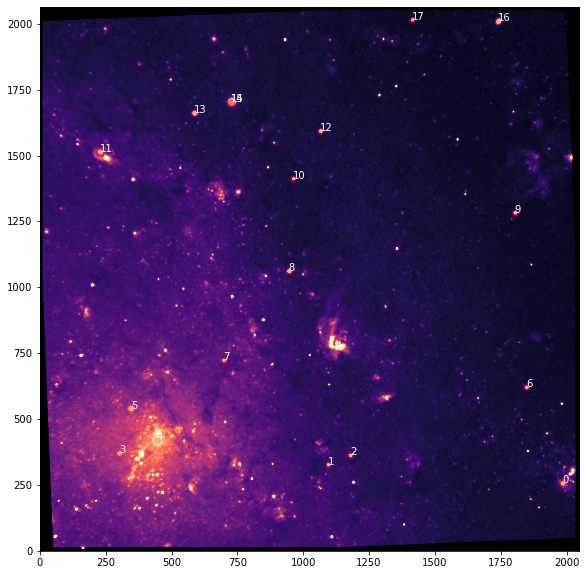

threshold =  1236579.0600307132
 id     xcentroid      ...        flux                 mag          
--- ------------------ ... ------------------ ----------------------
  1 1109.0295225129785 ... 2.4672127703669053    -0.9805165107446889
  2  61.00825853331961 ...  1.006552517873153 -0.0070910988999358365
  3 1382.7229276589803 ... 1.9261544701958218    -0.7117277823393968
  4  379.7199230231878 ... 1.0235352852059425  -0.025257047652854917
  5  443.4648451466445 ... 1.5510046786369627    -0.4765327696841592
  6 409.45493305975145 ...  1.232659009242958    -0.2271073855578269
  7  889.1370639189107 ... 1.0128319566673223   -0.01384348915093356
  8 466.80943742972454 ... 2.5573485491226045    -1.0194748085724878
  9  449.8944677194406 ... 1.1203955426786114   -0.12342843095287648
 10   772.535282160439 ... 1.0411707393360448   -0.04380488590701347
...                ... ...                ...                    ...
 44  866.2066962895223 ... 1.1003950730433631   -0.10387159298261384
 4

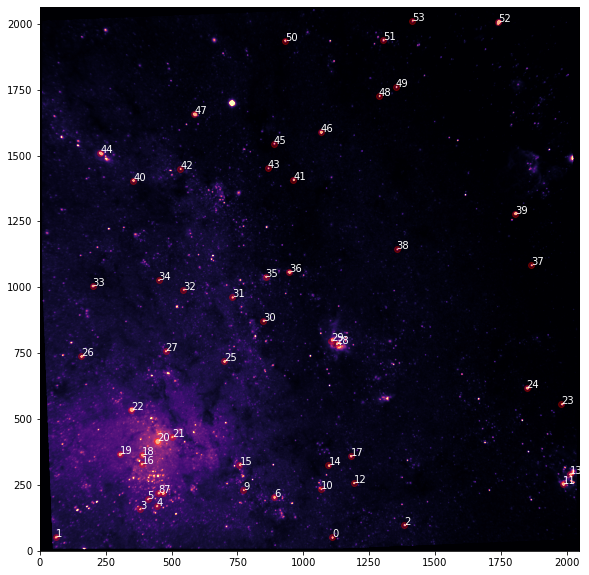

In [6]:
detection_etoiles_reference = detect_stars(deep_frame_reference)
detection_etoiles_desaligne = detect_stars(deep_frame_desaligne)

In [7]:
# data_centdois = pd.read_csv('M94_centroids.csv')
# Sn3_xi=data_centdois['x_SN3'][:150]
# Sn3_yi=data_centdois['y_SN3'][:150]

# # Sn2_xi=data_centdois['x_SN2'][:100]
# # Sn2_yi=data_centdois['y_SN2'][:100]

# Sn1_xi=data_centdois['x_SN1'][:150]
# Sn1_yi=data_centdois['y_SN1'][:150]



In [8]:
# idx=np.arange(0,len(Sn3_xi))

# detection_etoiles_reference = pd.DataFrame(idx,columns=['id'])
# detection_etoiles_reference['xcentroid'] = Sn3_xi
# detection_etoiles_reference['ycentroid'] = Sn3_yi

# detection_etoiles_desaligne = pd.DataFrame(idx, columns=['id'])
# # detection_etoiles_desaligne['xcentroid'] = Sn2_xi
# # detection_etoiles_desaligne['ycentroid'] = Sn2_yi
# detection_etoiles_desaligne['xcentroid'] = Sn1_xi
# detection_etoiles_desaligne['ycentroid'] = Sn1_yi

# etoiles_reference=detection_etoiles_reference
# etoiles_desaligne=detection_etoiles_desaligne


In [9]:
etoiles_reference=detection_etoiles_reference
etoiles_desaligne=detection_etoiles_desaligne

In [17]:
# Input the false detection to be removed from the list
mauvaises_etoiles_reference = [0]
mauvaises_etoiles_desaligne = [0]
# Remove bad detection to only use good stars for the alignment
etoiles_reference = np.delete(detection_etoiles_reference, mauvaises_etoiles_reference)
etoiles_desaligne = np.delete(detection_etoiles_desaligne, mauvaises_etoiles_desaligne)


In [ ]:
def match_stars_by_position(stars_reference, stars_desaligne, max_sep=20.0):
    """Keep only one-to-one matched stars before solving the transform."""
    ref_positions = np.vstack((stars_reference['xcentroid'], stars_reference['ycentroid'])).T.astype(float)
    des_positions = np.vstack((stars_desaligne['xcentroid'], stars_desaligne['ycentroid'])).T.astype(float)

    if len(ref_positions) < 2 or len(des_positions) < 2:
        raise RuntimeError('At least two stars are required in each cube for alignment.')

    distances = np.sqrt(np.sum((ref_positions[:, None, :] - des_positions[None, :, :])**2, axis=2))
    nearest_des_for_ref = np.argmin(distances, axis=1)
    nearest_ref_for_des = np.argmin(distances, axis=0)

    matched_ref_indices = []
    matched_des_indices = []
    matched_separations = []
    for ref_index, des_index in enumerate(nearest_des_for_ref):
        separation = distances[ref_index, des_index]
        if separation <= max_sep and nearest_ref_for_des[des_index] == ref_index:
            matched_ref_indices.append(ref_index)
            matched_des_indices.append(des_index)
            matched_separations.append(separation)

    if len(matched_ref_indices) < 2:
        raise RuntimeError(
            f'Only {len(matched_ref_indices)} matched star pair(s) found within {max_sep} pixels. '
            'Increase max_sep or remove mismatched detections manually.'
        )

    matched_reference = stars_reference[matched_ref_indices]
    matched_desaligne = stars_desaligne[matched_des_indices]
    match_table = QTable(
        data=(
            matched_reference['id'],
            matched_desaligne['id'],
            matched_reference['xcentroid'],
            matched_reference['ycentroid'],
            matched_desaligne['xcentroid'],
            matched_desaligne['ycentroid'],
            matched_separations,
        ),
        names=(
            'id_reference',
            'id_desaligne',
            'x_reference',
            'y_reference',
            'x_desaligne',
            'y_desaligne',
            'separation_pix',
        ),
    )
    return matched_reference, matched_desaligne, match_table


match_max_sep_pix = 20.0
etoiles_reference, etoiles_desaligne, table_matched_stars = match_stars_by_position(
    etoiles_reference,
    etoiles_desaligne,
    max_sep=match_max_sep_pix,
)
print(f'Matched {len(etoiles_reference)} star pairs within {match_max_sep_pix} pixels')
table_matched_stars


In [22]:
## Check the remaining stars for the alignment on the deep image with the wcs coordinate
def viz_deepframe_wcs(cube, stars):
    print(stars)
    plt.figure(figsize=(10,10))
    deep = cube.get_deep_frame()
    deep.imshow(vmin=np.nanpercentile(deep_frame_desaligne, 10),
                vmax=np.nanpercentile(deep_frame_desaligne, 99.9),
                cmap='magma',
                wcs=True)
    plt.scatter(stars['xcentroid'], stars['ycentroid'], alpha=0.3, color='red')
    #for i in stars:
        #plt.text(i['xcentroid'], i['ycentroid'], str(i['id']-1), color='white')
        #print(i['xcentroid'], i['ycentroid'], str(i['id']-1))
    plt.show()

[( 2, 1093.62814402,  326.81634101, 0.43039148, -0.12233881,  0.0806159 , 25, 0.,  5720256.31835938, 1.21767208, -0.21382587)
 ( 3, 1177.39809147,  361.8675014 , 0.42415194, -0.11479015,  0.07175349, 25, 0.,  5699054.20898438, 1.18108565, -0.18070349)
 ( 4,  300.97530949,  369.34383147, 0.42609388,  0.19322067, -0.00133985, 25, 0., 10239790.3125    , 1.96146967, -0.73145399)
 ( 5,  443.8019217 ,  418.86179136, 0.41774502,  0.11728666,  0.01752328, 25, 0., 15808042.6171875 , 2.51686449, -1.00214958)
 ( 6,  345.1463695 ,  539.41385613, 0.42788838,  0.18692957,  0.04450934, 25, 0., 41151321.640625  , 8.25723059, -2.29208603)
 ( 7, 1846.36810102,  619.95710676, 0.43661855, -0.08094213,  0.08727985, 25, 0.,  9879433.359375  , 2.15261042, -0.83241359)
 ( 8,  697.79088928,  722.36119262, 0.43336124,  0.092659  ,  0.18137282, 25, 0.,  7573953.50585938, 1.58361205, -0.49912199)
 ( 9,  945.24421401, 1061.11364225, 0.44584209,  0.07352333,  0.20952959, 25, 0., 16262784.26757812, 3.48817015, -1.35

<Figure size 720x720 with 0 Axes>

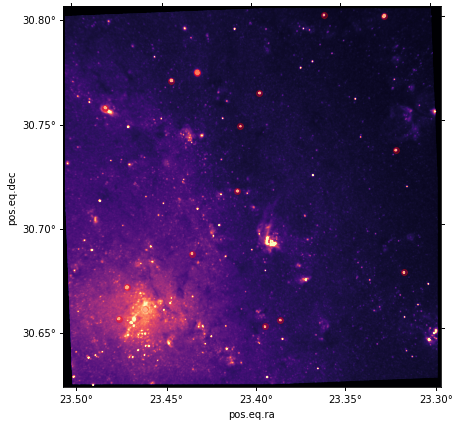

[( 2,   61.00825853,   52.0348304 , 0.42854221,  0.95225933, -0.2968203 , 25, 0.,  2453870.83300781,  1.00655252, -0.0070911 )
 ( 3, 1382.72292766,   97.48167101, 0.50749749, -0.2019095 ,  0.12308515, 25, 0.,  3335216.22949219,  1.92615447, -0.71172778)
 ( 4,  379.71992302,  157.76917111, 0.48417378,  0.75857245,  0.00493492, 25, 0.,  2022971.22363281,  1.02353529, -0.02525705)
 ( 5,  443.46484515,  169.14247144, 0.48978444,  0.49345697,  0.01684068, 25, 0.,  2832508.359375  ,  1.55100468, -0.47653277)
 ( 6,  409.45493306,  195.56909596, 0.49192293,  0.65386389,  0.04764449, 25, 0.,  2313090.61816406,  1.23265901, -0.22710739)
 ( 7,  889.13706392,  202.69243718, 0.46423675,  0.60062943,  0.25102331, 25, 0.,  2419905.94335938,  1.01283196, -0.01384349)
 ( 8,  466.80943743,  217.45424847, 0.47151835,  0.39387027,  0.08608064, 25, 0.,  4980193.453125  ,  2.55734855, -1.01947481)
 ( 9,  449.89446772,  219.10021776, 0.45795434,  0.8961707 ,  0.43177799, 25, 0.,  2589681.41601562,  1.1203955

<Figure size 720x720 with 0 Axes>

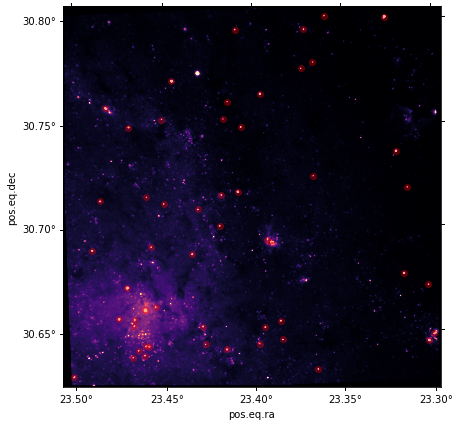

In [23]:
## Check remaining stars
viz_deepframe_wcs(cube_reference, etoiles_reference)
viz_deepframe_wcs(cube_desaligne, etoiles_desaligne)


In [24]:
## Get WCS of the stars
wcs_etoiles_reference = cube_reference.pix2world((etoiles_reference['xcentroid'], etoiles_reference['ycentroid']))
wcs_etoiles_desaligne = cube_desaligne.pix2world((etoiles_desaligne['xcentroid'], etoiles_desaligne['ycentroid']))

In [25]:
## Generate table for both cubes with WCS vs pixels for each stars
table_reference = QTable(data=(etoiles_reference['id'], etoiles_reference['xcentroid'], etoiles_reference['ycentroid'], wcs_etoiles_reference.T[0], wcs_etoiles_reference.T[1]), names=('id','x_in_image','y_in_image','right_ascension','declination'))
table_desaligne = QTable(data=(etoiles_desaligne['id'], etoiles_desaligne['xcentroid'], etoiles_desaligne['ycentroid'], wcs_etoiles_desaligne.T[0], wcs_etoiles_desaligne.T[1]), names=('id','x_in_image','y_in_image','right_ascension','declination'))


unknown|WARNING| /opt/conda/lib/python3.8/site-packages/astropy/table/column.py:329: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)

unknown|WARNING| /opt/conda/lib/python3.8/site-packages/astropy/table/column.py:329: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)



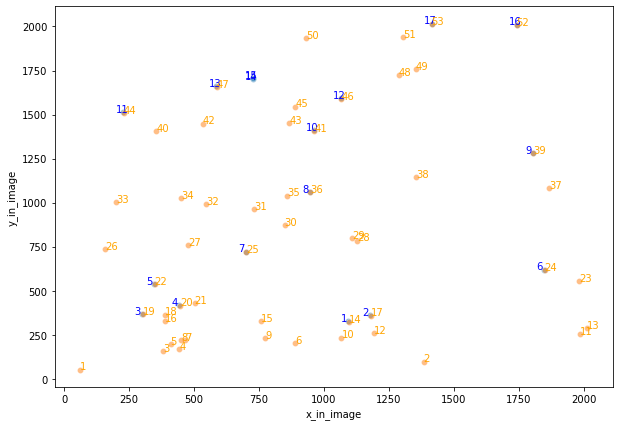

In [26]:
## Check miss-alignment
plt.figure(figsize=(10,7))
sns.scatterplot(data=table_reference, x=table_reference['x_in_image'], y=table_reference['y_in_image'], alpha=0.5)
sns.scatterplot(data=table_desaligne, x=table_desaligne['x_in_image'], y=table_desaligne['y_in_image'], alpha=0.5)
for i in table_reference:
    plt.text(i['x_in_image']-30, i['y_in_image'], str(i['id']-1), color='blue')
for i in table_desaligne:
    plt.text(i['x_in_image'], i['y_in_image'], str(i['id']-1), color='orange')

In [27]:
## The rotation and translation parameter are estimated with the SVD method
## Method used : http://nghiaho.com/?page_id=671

x_positions_reference = table_reference['x_in_image']
y_positions_reference = table_reference['y_in_image']
x_positions_desaligne = table_desaligne['x_in_image']
y_positions_desaligne = table_desaligne['y_in_image']

## Covert position lists into array
positions_reference = np.vstack((x_positions_reference, y_positions_reference)).T
positions_desaligne = np.vstack((x_positions_desaligne, y_positions_desaligne)).T

## Calculate centroid vectors of the stars
centroid_reference = np.nanmean(positions_reference, axis=0)
centroid_desaligne = np.nanmean(positions_desaligne, axis=0)

## Reposition the stars
etoiles_reference_centroid = positions_reference - centroid_reference
etoiles_desaligne_centroid = positions_desaligne - centroid_desaligne
etoiles_reference_centroid = etoiles_reference_centroid.T
etoiles_desaligne_centroid = etoiles_desaligne_centroid.T

## Calculate the covariance matrix
H = etoiles_desaligne_centroid.dot(etoiles_reference_centroid.T)

## Calculate the rotation using the SVD method
U, S, V = np.linalg.svd(H)
R = V.T.dot(U.T) # Pas la formule sur la site mais ce qu'il fait sur github, parce que V est déjà transposée

## Calculate the translation
t = centroid_reference - R.dot(centroid_desaligne)

## Invert the matrix to get the right shape (R*(A+R^-1*t)=B) for orb.utils.image.transform_frame()
R_inv = np.linalg.inv(R)
translation_sans_rotation = R_inv.dot(t)

## Calculate the angle of rotation from the rotation matrix
dtheta = np.rad2deg(np.arctan2(R[1,0], R[0,0]))



ValueError: shapes (2,53) and (17,2) not aligned: 53 (dim 1) != 17 (dim 0)

In [28]:
parametres_transformation = {'dx':translation_sans_rotation[0],
              'dy':translation_sans_rotation[1],
              'dtheta':-dtheta}

os.makedirs('M33_alignments', exist_ok=True)
parametres_align_cube_corrige = open(f'M33_alignments/parametres_align_cube_corrige_{filter_to_align}_{field}.txt', 'w')
json.dump(parametres_transformation, parametres_align_cube_corrige) 
parametres_align_cube_corrige.close()

NameError: name 'translation_sans_rotation' is not defined

In [29]:
print(parametres_transformation)

NameError: name 'parametres_transformation' is not defined

In [ ]:
# parametres_transformation